In [1]:
import pandas as pd
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('loan_approval_data.csv')
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [3]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [6]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# filling missing values

In [7]:
cat_data = df.select_dtypes(include=['object']).columns
num_data = df.select_dtypes(include=['number']).columns

In [8]:
# it fills the null values with strategy
from sklearn.impute import SimpleImputer

In [9]:
num_imp = SimpleImputer(strategy = 'mean')
df[num_data] = num_imp.fit_transform(df[num_data])

In [10]:
cat_imp = SimpleImputer(strategy = 'most_frequent')
df[cat_data] =cat_imp.fit_transform(df[cat_data])

In [11]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

Text(0.5, 1.0, 'approved pr not')

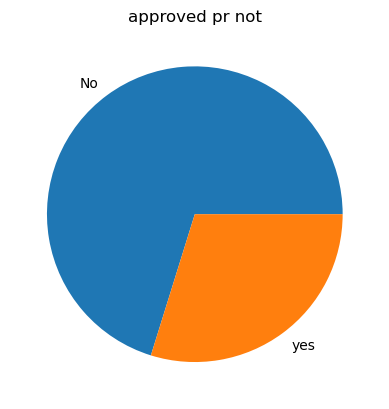

In [12]:
import matplotlib.pyplot as plt
count_classes = df['Loan_Approved'].value_counts()
plt.pie(count_classes , labels=['No' ,"yes"])
plt.title("approved pr not")

[Text(0, 0, '621'), Text(0, 0, '379')]

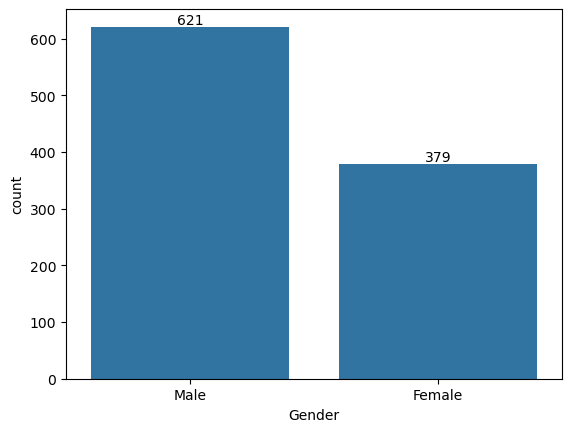

In [13]:
### comparisions 
import seaborn as sns
gen_classes = df["Gender"].value_counts()
ax=sns.barplot(gen_classes)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

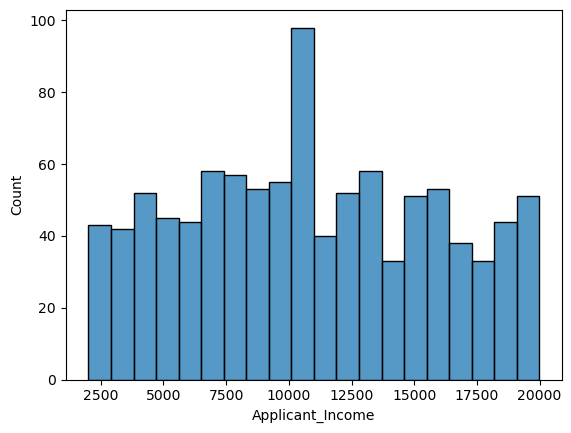

In [14]:
# income 
sns.histplot(data = df , x='Applicant_Income' , bins = 20)      

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

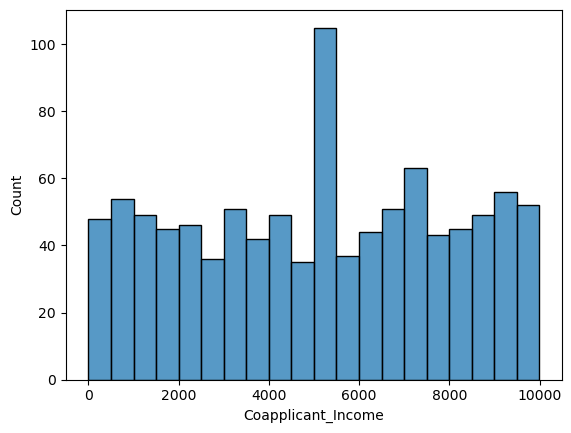

In [15]:
sns.histplot(data= df,x='Coapplicant_Income',bins = 20)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

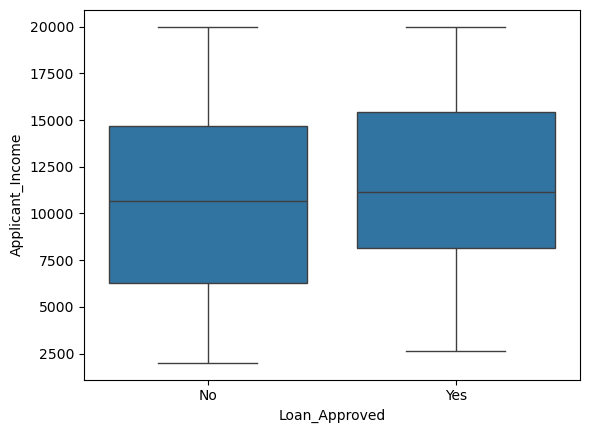

In [16]:
## outliers ditection
sns.boxplot(data = df ,x="Loan_Approved", y="Applicant_Income")

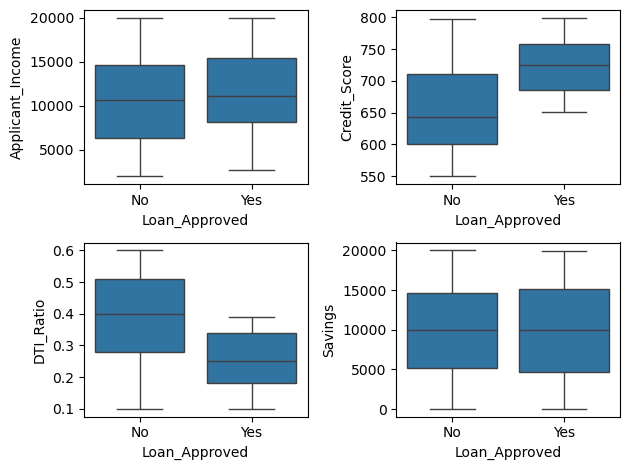

In [17]:
fig,axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")
plt.tight_layout()

<Axes: xlabel='Loan_Approved', ylabel='Count'>

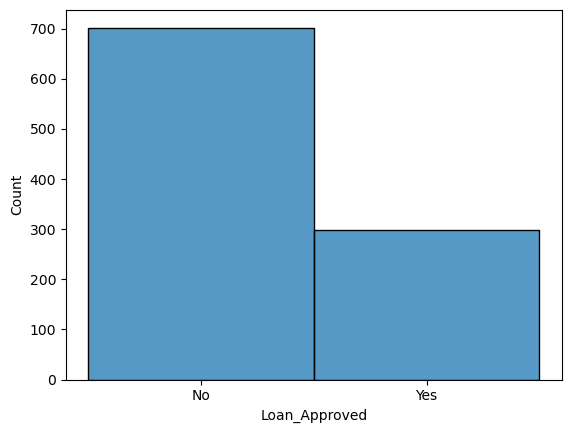

In [18]:
# credit scored with loan approved
sns.histplot(data=df,x="Loan_Approved",bins=50,multiple="dodge")

In [19]:
#remove appkicant ID
df=df.drop("Applicant_ID" , axis=1)

In [20]:
df.head(2)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No


# Encoding

In [21]:
# converting cat to numerical 
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [22]:
# label encoder converts the text to number within the column
#oneHot does it by creating multiple columns and assigns it

In [23]:
# if we have any two ansers in any column (ie) yes or NO, True or False , Male or Female , phone or laptop
  #here we use label encoder and it makes 1 and 0 in the same col
#if we have multiple values in a col (ie) tul,jk,kow,poor if the value is jk then jk will be considerd as 1 (ie) for each person each col is created
 # for this oneHot encoding is used
  

In [24]:
df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [25]:
df.Education_Level.unique()
df.Loan_Approved.unique()

array(['No', 'Yes'], dtype=object)

In [26]:
le=LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [27]:
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)
df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)                 

In [28]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Correlation Heatmap

<Axes: >

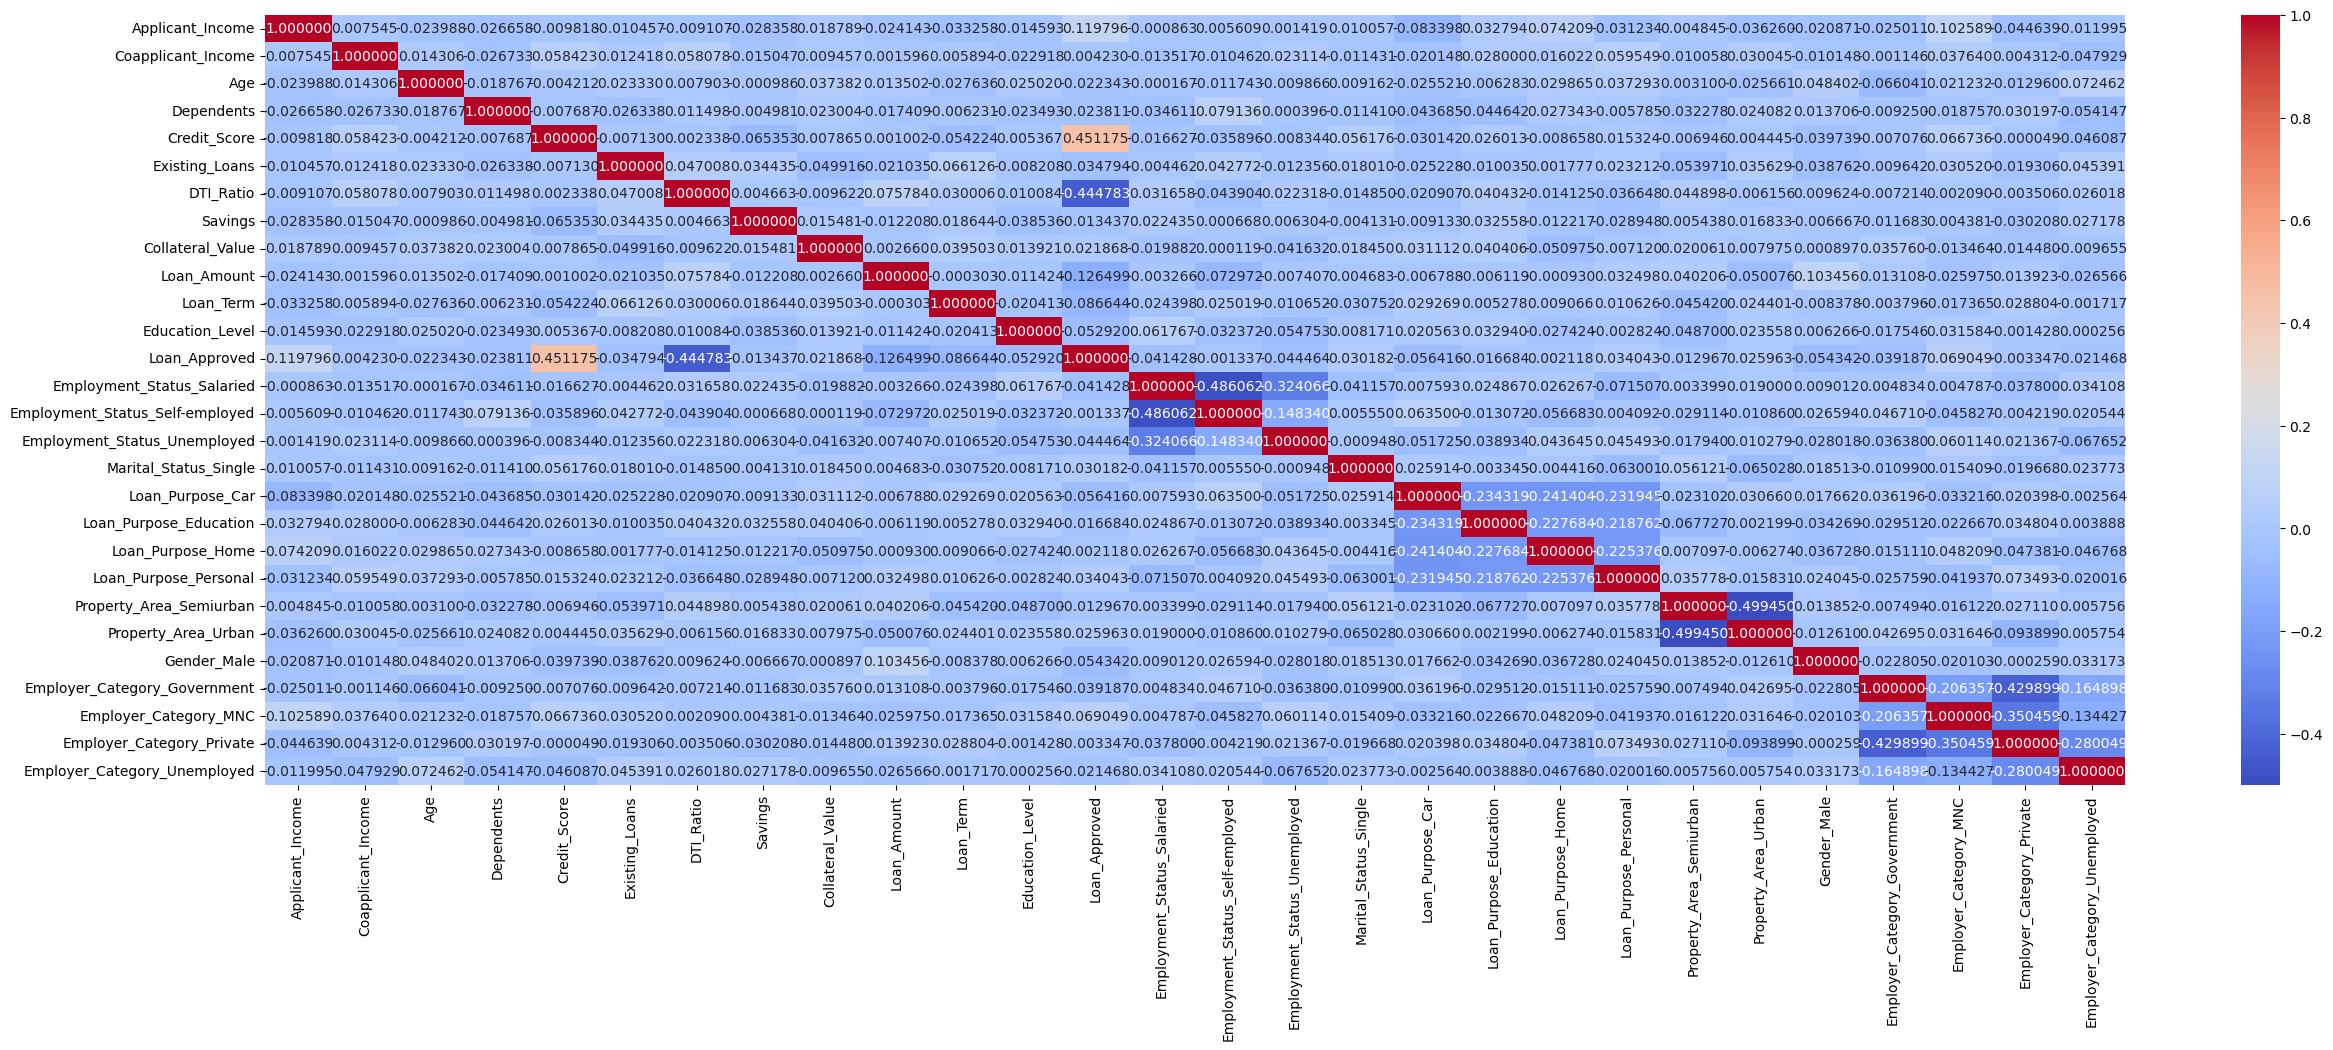

In [29]:
#used to check relations between the numerical columns most use full for linear relational data
nums_cols = df.select_dtypes(include="number")
corr_met = nums_cols.corr()
plt.figure(figsize=(30,10))
sns.heatmap(corr_met,annot=True,fmt="2f",cmap="coolwarm")

In [30]:
nums_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Train-Test-Split + Feature Scaling

In [31]:
x= df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [32]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape
x_test.shape

(200, 27)

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
x_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]],
      shape=(800, 27))

# Train and evaluate Model

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model = LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred = log_model.predict(x_test_scaled)
# as per the prolem statements wwe have to use precesion on priority beacuse from the total number of loan approvals how many wanted to be actually approved is calulated by precision
print("precision :",precision_score(y_test,y_pred))
print("confusion matrix :",confusion_matrix(y_test,y_pred))
print("recall :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("accuracy :",accuracy_score(y_test,y_pred))

precision : 0.7833333333333333
confusion matrix : [[126  13]
 [ 14  47]]
recall : 0.7704918032786885
f1 score : 0.7768595041322314
accuracy : 0.865


In [38]:
# knn
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)
y_pred = knn_model.predict(x_test_scaled)
# as per the prolem statements wwe have to use precesion on priority beacuse from the total number of loan approvals how many wanted to be actually approved is calulated by precision
print("precision :",precision_score(y_test,y_pred))
print("confusion matrix :",confusion_matrix(y_test,y_pred))
print("recall :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("accuracy :",accuracy_score(y_test,y_pred))

precision : 0.7222222222222222
confusion matrix : [[129  10]
 [ 35  26]]
recall : 0.4262295081967213
f1 score : 0.5360824742268041
accuracy : 0.775


In [39]:
#naive baise
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred = nb_model.predict(x_test_scaled)
# as per the prolem statements wwe have to use precesion on priority beacuse from the total number of loan approvals how many wanted to be actually approved is calulated by precision
print("precision :",precision_score(y_test,y_pred))
print("confusion matrix :",confusion_matrix(y_test,y_pred))
print("recall :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("accuracy :",accuracy_score(y_test,y_pred))

precision : 0.8035714285714286
confusion matrix : [[128  11]
 [ 16  45]]
recall : 0.7377049180327869
f1 score : 0.7692307692307693
accuracy : 0.865


# best model on the basesw of precesion is naive bayes

# feature engineering

In [46]:
# we done it simply
df['DTI_ratio_sq'] = df['DTI_Ratio']**2
df['Credit_score']=df['Credit_Score']**2
features = df.drop(columns=['Loan_Approved','DTI_Ratio','Credit_Score'])
target = df['Loan_Approved']
x_train,x_test,y_train,y_test = train_test_split(features, target,test_size=0.2,random_state=42)
std_scl = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [47]:
#naive baise
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred = nb_model.predict(x_test_scaled)
# as per the prolem statements wwe have to use precesion on priority beacuse from the total number of loan approvals how many wanted to be actually approved is calulated by precision
print("precision :",precision_score(y_test,y_pred))
print("confusion matrix :",confusion_matrix(y_test,y_pred))
print("recall :",recall_score(y_test,y_pred))
print("f1 score :",f1_score(y_test,y_pred))
print("accuracy :",accuracy_score(y_test,y_pred))

precision : 0.7833333333333333
confusion matrix : [[126  13]
 [ 14  47]]
recall : 0.7704918032786885
f1 score : 0.7768595041322314
accuracy : 0.865
